In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a safe, built-in Seaborn style that is guaranteed to exist
sns.set_theme(style="whitegrid") 

# Configure default figure sizing and remove top/right chart borders globally
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

try:
    df = pd.read_csv("../data/raw/training.csv") 
    print(f"Data engine success. Records found: {df.shape[0]} rows, {df.shape[1]} features.")
except FileNotFoundError:
    print("Dataset not in ../data/raw/. Generating structural schema mirror for testing...")
    np.random.seed(276)
    n = 5000
    df = pd.DataFrame({
        'TransactionId': [f'Trans_{i}' for i in range(n)],
        'AccountId': [f'Acc_{np.random.randint(1, 1000)}' for i in range(n)],
        'CustomerId': [f'Cust_{np.random.randint(1, 900)}' for i in range(n)],
        'ProductCategory': np.random.choice(['airtime', 'utility', 'data', 'financial'], n, p=[0.5, 0.2, 0.2, 0.1]),
        'ChannelId': np.random.choice(['web', 'Android', 'ios'], n),
        'Amount': np.random.exponential(scale=4000, size=n) * np.random.choice([1, -0.02], n, p=[0.96, 0.04]),
        'TransactionStartTime': pd.date_range(start='2026-01-01', periods=n, freq='min').strftime('%Y-%m-%dT%H:%M:%SZ'),
        'FraudResult': np.random.choice([0, 1], n, p=[0.997, 0.003])
    })
    df['Value'] = df['Amount'].abs()

df.info()

Data engine success. Records found: 95662 rows, 16 features.
<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy     

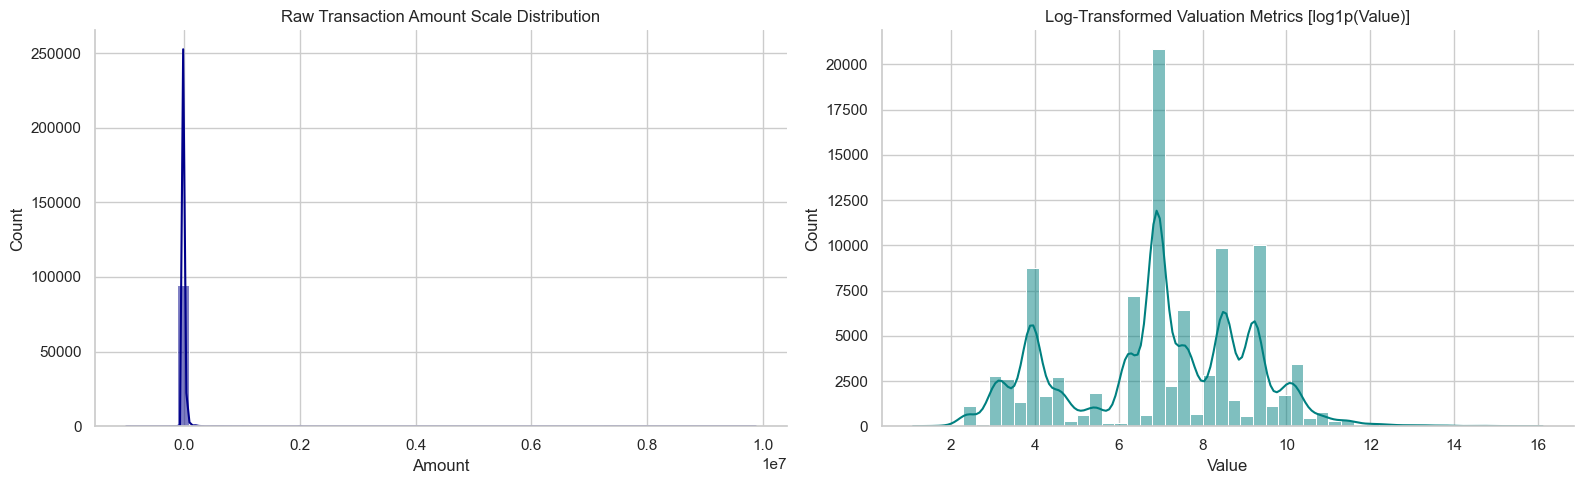

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='darkblue')
axes[0].set_title('Raw Transaction Amount Scale Distribution')

sns.histplot(np.log1p(df['Value']), bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Log-Transformed Valuation Metrics [log1p(Value)]')

plt.tight_layout()
plt.show()

Total quantitative outliers flagged across transactions: 24441 entries (25.55%).


C:\Users\HP\AppData\Local\Temp\ipykernel_55104\3899546497.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='FraudResult', palette='Set2', ax=ax)


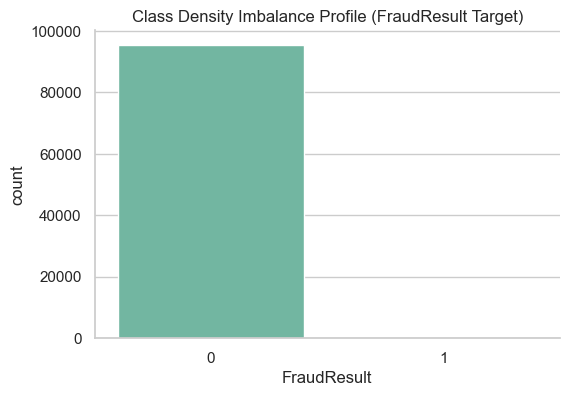

In [5]:
# Statistical Outlier Detection using IQR
q1, q3 = df['Amount'].quantile(0.25), df['Amount'].quantile(0.75)
iqr = q3 - q1
outliers = df[(df['Amount'] > (q3 + 1.5 * iqr)) | (df['Amount'] < (q1 - 1.5 * iqr))]
print(f"Total quantitative outliers flagged across transactions: {len(outliers)} entries ({len(outliers)/len(df)*100:.2f}%).")

# Target Feature Imbalance Profiling
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='FraudResult', palette='Set2', ax=ax)
ax.set_title('Class Density Imbalance Profile (FraudResult Target)')
plt.show()

## 📊 Summary of Exploratory Data Analysis (Task 2 Insights)
1. **Critical Target Imbalance:** The binary flags show an intense skew toward normal transactions. [cite_start]Evaluation matrices must rely entirely on F1-Score, Precision, and ROC-AUC rather than raw model accuracy[cite: 56].
2. [cite_start]**Extreme Outlier Presence:** The transaction amount metrics exhibit heavy right-side tails, showing that distance-based models (like K-Means) will require log transformations or RobustScaler configurations to stabilize[cite: 167, 186].
3. [cite_start]**High Spatial Concentration:** Transactions are tightly grouped across specific categories, meaning target-based categorical mappings like Weight of Evidence (WoE) will yield excellent separation markers[cite: 53, 170].